In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import math

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import time

In [3]:
df = pd.read_csv('dataset_riesgo_hipertension.csv')
df=df.dropna()

In [4]:
# --- 2. Definir Características (X) y Objetivo (y) ---
features = ['Edad', 'IMC', 'PresionArterial', 'ConsumoSal', 'ActividadFisica']
target = 'RiesgoHipertension'


In [10]:
# Convertir a arrays de numpy para Keras
X = df[features]
y = df[target]

In [82]:
capa_salida = model.layers[0]
pesos_w, sesgos_b = capa_salida.get_weights()

print("--- Coeficientes de la Capa de Salida (W) ---")
# Los pesos W son una matriz, por lo que aplanamos para coincidir con la lista de features
pesos_plana = pesos_w.flatten()
for feature, peso in zip(features, pesos_plana):
    print(f"{feature:<20}: {peso:.6f}")

print("\n--- Sesgo de la Capa de Salida (b) ---")
print(f"Sesgo (Intercepto): {sesgos_b[0]:.6f}")

--- Coeficientes de la Capa de Salida (W) ---
Edad                : 0.021599
IMC                 : -0.019410
PresionArterial     : 0.009714
ConsumoSal          : 0.459960
ActividadFisica     : -0.999114

--- Sesgo de la Capa de Salida (b) ---
Sesgo (Intercepto): -0.455339


In [26]:
# --- 3. Dividir los Datos ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [27]:
X_test.count()

,0
Edad,60
IMC,60
PresionArterial,60
ConsumoSal,60
ActividadFisica,60


In [64]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=[5])
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
epochs_hist=model.fit(X_train, y_train, epochs=500, verbose=0)
print("hecho")

hecho


In [58]:
print(epochs_hist.history.keys())

dict_keys(['accuracy', 'loss'])


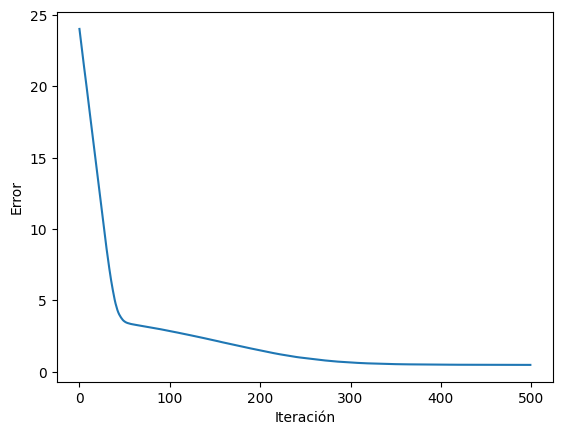

In [67]:
plt.xlabel("Iteración")
plt.ylabel("Error")
plt.plot(epochs_hist.history["loss"])

In [76]:
final_accuracy = epochs_hist.history['accuracy'][-1]
final_loss = epochs_hist.history['loss'][-1]
print(f'Precisión final: {final_accuracy}')
print(f'Error final: {final_loss}')

Precisión final: 0.7714285850524902
Error final: 0.4764283299446106


In [77]:
predictions = model.predict(X_test)
# Convertir probabilidades (ej. 0.8) a clases binarias (0 o 1)
predictions = (predictions > 0.5).astype(int)
predictions.reshape(1,60)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1]])

In [78]:
# --- 10. Matriz de Confusión y Visualización ---
matrixC = metrics.confusion_matrix(y_test, predictions)
print("\nMatriz de Confusión:")
print(matrixC)


Matriz de Confusión:
[[27 15]
 [ 5 13]]


<Figure size 600x600 with 0 Axes>

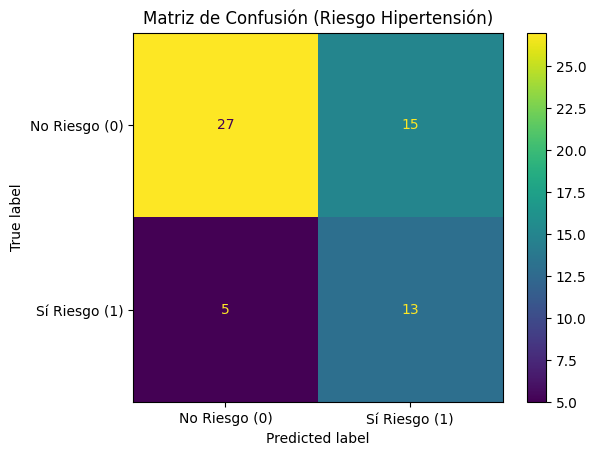

In [79]:
plt.figure(figsize=(6, 6))
cm_display = metrics.ConfusionMatrixDisplay(matrixC, display_labels=['No Riesgo (0)', 'Sí Riesgo (1)'])
cm_display.plot()
plt.title('Matriz de Confusión (Riesgo Hipertensión)')
plt.show()

In [80]:
# Calcular Matriz de Confusión
matrixC = confusion_matrix(y_test, predictions)
print(f"Matriz de Confusión:\n{matrixC}")

# 1. Exactitud
exactitud = accuracy_score(y_test, predictions)
print(f"Exactitud: {exactitud:.4f}")

# 2. Precisión (para la clase Positiva, o 1)
precision = precision_score(y_test, predictions)
print(f"Precisión: {precision:.4f}")

# 3. Exhaustividad (Recall) (para la clase Positiva, o 1)
exhaustividad = recall_score(y_test, predictions)
print(f"Exhaustividad: {exhaustividad:.4f}")

# 4. F1-Score
f1 = f1_score(y_test, predictions)
print(f"F1-Score: {f1:.4f}")

# 5. Error
error = 1 - exactitud
print(f"Error: {error:.4f}")

# O usa el informe completo:
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test, predictions))

Matriz de Confusión:
[[27 15]
 [ 5 13]]
Exactitud: 0.6667
Precisión: 0.4643
Exhaustividad: 0.7222
F1-Score: 0.5652
Error: 0.3333

--- Informe de Clasificación ---
              precision    recall  f1-score   support

           0       0.84      0.64      0.73        42
           1       0.46      0.72      0.57        18

    accuracy                           0.67        60
   macro avg       0.65      0.68      0.65        60
weighted avg       0.73      0.67      0.68        60

